In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/merged_submissions.jsonl

/content/drive/MyDrive/merged_submissions.jsonl


In [3]:
import torch
print(torch.cuda.is_available())  # Should be True

True


In [15]:
import pandas as pd
from networkx.classes import non_neighbors
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import logging
from sklearn.decomposition import IncrementalPCA
from sklearn.cluster import MiniBatchKMeans
from bertopic.vectorizers import OnlineCountVectorizer
import re
import emoji
from langdetect import detect
from multiprocessing import Pool, cpu_count
import spacy
import os
import psutil

In [9]:
# Setup logging
logging.basicConfig(format="%(asctime)s — %(levelname)s — %(message)s", level=logging.INFO)
logger = logging.getLogger(__name__)

In [10]:
# Load spaCy once globally per process
_nlp = None

def init_spacy():
    global _nlp
    _nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

def clean_text(text):
    if not isinstance(text, str) or len(text) < 5:
        return None

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove emojis
    text = emoji.replace_emoji(text, replace='')

    # Remove Reddit mentions/markdown (e.g. u/username, r/subreddit, > quotes)
    text = re.sub(r"u/\w+|r/\w+|>\s.*", "", text)

    # Remove special chars/punctuation except for words
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Lowercase
    text = text.lower()

    # Ensure English language
    if not is_english(text):
        return None

    return text.strip()


def process_docs_parallel(docs, batch_size=5000):
    logger = logging.getLogger(__name__)
    logger.info(f"Starting text cleaning with {cpu_count()} workers...")

    with Pool(processes=cpu_count()) as pool:
        cleaned = pool.map(clean_text, docs)

    # Filter out None or short entries
    cleaned = [doc for doc in cleaned if doc and len(doc.split()) > 3]
    logger.info(f"Finished cleaning. Remaining docs: {len(cleaned)}")

    # Lemmatization (batched with spaCy)
    logger.info("Starting lemmatization with spaCy...")
    final_docs = []
    init_spacy()  # ensure nlp is loaded in main process too
    for doc in _nlp.pipe(cleaned, batch_size=1000):
        tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
        if tokens:
            final_docs.append(" ".join(tokens))

    logger.info(f"Lemmatization complete. Final docs: {len(final_docs)}")
    return final_docs


In [11]:
def process_docs(chunk):
    chunk = chunk[['title', 'selftext']].fillna('').astype(str)
    texts = (chunk['title'] + ' ' + chunk['selftext']).tolist()
    return process_docs_parallel(texts)

In [12]:
def batched_encode(model, docs, batch_size=64):
    embeddings = []
    dataloader = DataLoader(docs, batch_size=batch_size)
    for batch in tqdm(dataloader, desc="Encoding batches"):
        emb = model.encode(batch, convert_to_numpy=True, show_progress_bar=False)
        embeddings.extend(emb)
    return embeddings

In [13]:
def run_topic_modeling_partial(
    path,
    chunk_size=100_000,
    batch_size=64,
    min_topic_size=10,
    checkpoint_every=5,
    output_dir="bertopic_output"
):
    os.makedirs(output_dir, exist_ok=True)

    # Device setup
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    logger.info(f"Using device: {device}")

    # Data loader
    reader = pd.read_json(path, lines=True, chunksize=chunk_size)

    # Embedding model
    embedding_model = SentenceTransformer(
        'flax-sentence-embeddings/reddit_single-context_mpnet-base',
        device=device
    )

    # Dimensionality reduction
    umap_model = IncrementalPCA(n_components=15)

    # Clustering
    cluster_model = MiniBatchKMeans(
        n_clusters=100,
        batch_size=1000,
        random_state=42
    )

    # Vectorizer
    vectorizer_model = OnlineCountVectorizer(
        stop_words="english",
        decay=0.005,
        min_df=1,
        ngram_range=(1, 2)
    )

    # BERTopic
    topic_model = BERTopic(
        embedding_model=None,  # We'll use precomputed embeddings
        umap_model=umap_model,
        hdbscan_model=cluster_model,
        vectorizer_model=vectorizer_model,
        nr_topics=20,
        min_topic_size=min_topic_size,
        calculate_probabilities=True,
        verbose=True,
    )

    all_docs = []
    all_topics = []

    logger.info("Starting chunked topic modeling...")

    for i, chunk in enumerate(reader):
        try:
            logger.info(f"Processing chunk {i + 1}")
            docs = process_docs(chunk)
            if not docs:
                logger.warning(f"Chunk {i + 1} is empty after preprocessing. Skipping.")
                continue

            embeddings = batched_encode(embedding_model, docs, batch_size=batch_size)
            logger.info(f"Chunk {i + 1}: {len(docs)} documents encoded.")

            if i == 0:
                topic_model.fit(docs, embeddings=embeddings)
                logger.info("Initial fit completed.")
            else:
                topic_model.partial_fit(docs, embeddings=embeddings)
                logger.info(f"Partial fit completed on chunk {i + 1}.")

            all_docs.extend(docs)
            all_topics.extend(topic_model.topics_)

            # Save intermediate results
            if (i + 1) % checkpoint_every == 0:
                checkpoint_path = os.path.join(output_dir, f"bertopic_checkpoint_{i+1}.model")
                topic_model.save(checkpoint_path)
                logger.info(f"Checkpoint saved at: {checkpoint_path}")

        except Exception as e:
            logger.error(f"Error processing chunk {i + 1}: {str(e)}", exc_info=True)

    # Final save
    topic_model.topics_ = all_topics
    final_model_path = os.path.join(output_dir, "bertopic_final.model")
    topic_model.save(final_model_path)
    logger.info(f"Final model saved at: {final_model_path}")

    # Save topics CSV
    topics_df = pd.DataFrame(all_topics)
    topics_csv_path = os.path.join(output_dir, "all_topics.csv")
    topics_df.to_csv(topics_csv_path, index=False)
    logger.info(f"Topics saved to: {topics_csv_path}")

    return topic_model

In [16]:
path = "/content/drive/MyDrive/merged_submissions.jsonl"
topic_model = run_topic_modeling_partial(path)

# Get topic info
topic_info = topic_model.get_topic_info()
topic_info.to_csv('./TopicModelling_merged_reddit_embedding_model.csv', index=False)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
for col in df.columns:
    print(col)

In [ ]:
print(df.shape)
print(df.info())
print(df.describe(include='all'))

(1390597, 135)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1390597 entries, 0 to 1390596
Columns: 135 entries, archived to year
dtypes: bool(2), datetime64[ns, UTC](1), float64(68), int32(1), int64(3), object(60)
memory usage: 1.4+ GB
None


In [ ]:
Missing values by column

In [ ]:
print(df.isnull().sum().sort_values(ascending=False).head(20))

year
2008      7951
2009     25126
2010     25763
2011     29626
2012     68243
2013     84096
2014     75806
2015     92896
2016    140951
2017    123114
2018    141604
2019    110349
2020    118498
2021     92736
2022     78787
2023     81077
2024     93974
Name: count, dtype: int64


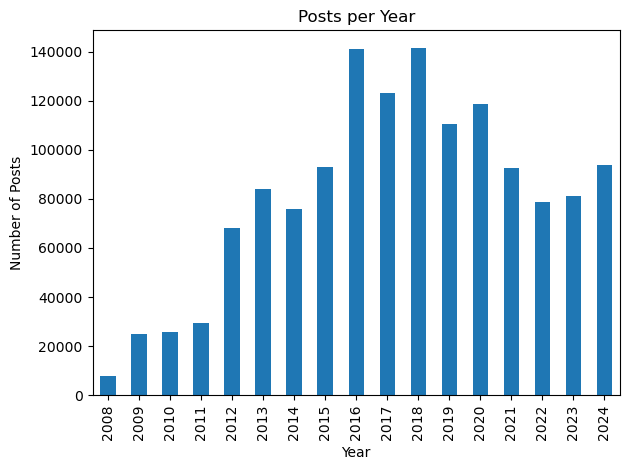

In [ ]:
df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s', utc=True)
df['year'] = df['created_utc'].dt.year
year_counts = df['year'].value_counts().sort_index()
print(year_counts)
year_counts = df.groupby(df['created_utc'].dt.year).size()

import matplotlib.pyplot as plt

year_counts.sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Posts')
plt.title('Posts per Year')
plt.tight_layout()
plt.show()

In [ ]:
Topic modelling

In [ ]:
import logging

# Setup basic logging configuration
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

In [ ]:
import pandas as pd

sample_df = df.sample(n=500, random_state=42).fillna({"title": "", "selftext": ""})
docs = (sample_df['title'] + " " + sample_df['selftext']).tolist()
logger.info(f"Prepared {len(docs)} documents for topic modeling")

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

logger.info("Loading embedding model")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

logger.info("Initializing vectorizer and BERTopic")
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_df=0.85,
    min_df=2,
    max_features=3000
)
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    nr_topics="auto",
    top_n_words=10,
    calculate_probabilities=True,
    verbose=True  # Enables BERTopic’s built-in progress logging  [oai_citation:2‡Stack Overflow](https://stackoverflow.com/questions/76856592/jupyter-keeps-crashing-when-using-bertopics-fit-transform?utm_source=chatgpt.com)
)

In [ ]:
logger.info("Starting fit_transform() on sample documents")
topics, probs = topic_model.fit_transform(docs)
logger.info("Completed BERTopic modeling")

logger.info("Retrieving and displaying topic info")
topic_info = topic_model.get_topic_info()
topic_info.head()

In [ ]:
try:
    logger.info("Generating interactive topic visualization")
    fig = topic_model.visualize_topics()
    fig.write_html("sample_topic_vis.html")
    logger.info("Saved visualization to sample_topic_vis.html")
except Exception as e:
    logger.error(f"Visualization failed: {e}")